In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.collections import LineCollection
import ast

sns.set_theme(style="whitegrid")

print("Bắt đầu đọc và xử lý các tệp CSV...")

try:
    nodes_df = pd.read_csv('data/nodes.csv')
    edges_df = pd.read_csv('data/edges.csv')
    edges_df['los'] = edges_df['los'].apply(ast.literal_eval)
    edges_df['weight'] = edges_df['weight'].apply(ast.literal_eval)
except FileNotFoundError as e:
    print(f"\nKhông tìm thấy tệp '{e.filename}'.")

print("==================================================")
print(" Phân tích tệp: nodes.csv")
print("==================================================")
print("\n(1) 5 dòng dữ liệu đầu tiên:")
display(nodes_df.head())

print(f"\n(2) Tổng số hàng: {len(nodes_df):,}")

print("\n(3) Thông tin cơ bản (.info()):")
nodes_df.info(memory_usage='deep')

print("\n(4) Số lượng giá trị rỗng mỗi cột:")
print(nodes_df.isnull().sum())
print("\n")

print("==================================================")
print(" Phân tích tệp: edges.csv")
print("==================================================")
print("\n(1) 5 dòng dữ liệu đầu tiên:")
display(edges_df.head())

print(f"\n(2) Tổng số hàng: {len(edges_df):,}")

print("\n(3) Thông tin cơ bản (.info()):")
edges_df.info(memory_usage='deep')

print("\n(4) Số lượng giá trị rỗng mỗi cột:")
print(edges_df.isnull().sum())

Bắt đầu đọc và xử lý các tệp CSV...
 Phân tích tệp: nodes.csv

(1) 5 dòng dữ liệu đầu tiên:


,osmid,y,x
0,11393695758,10.786110,106.700575
1,6627521383,10.776819,106.722604
2,5740298577,10.769427,106.725292
3,13513813103,10.788409,106.699531
4,13513813129,10.787031,106.698289



(2) Tổng số hàng: 38,646

(3) Thông tin cơ bản (.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38646 entries, 0 to 38645
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   osmid   38646 non-null  int64  
 1   y       38646 non-null  float64
 2   x       38646 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 905.9 KB

(4) Số lượng giá trị rỗng mỗi cột:
osmid    0
y        0
x        0
dtype: int64


 Phân tích tệp: edges.csv

(1) 5 dòng dữ liệu đầu tiên:


,u,v,osmid,highway,length,geometry,los,weight
0,11393695758,13513813140,308848875,residential,36.227606,"LINESTRING (106.700575 10.7861099, 106.7008135...","[1.0, 1.0, 1.0, 1.0, 1.001, 1.002, 1.006, 1.01...","[36.228, 36.228, 36.228, 36.228, 36.264, 36.3,..."
1,11393695758,6110770486,308848875,residential,101.498002,"LINESTRING (106.700575 10.7861099, 106.6999068...","[1.0, 1.0, 1.0, 1.0, 1.001, 1.002, 1.006, 1.01...","[101.498, 101.498, 101.498, 101.498, 101.6, 10..."
2,11393695758,2037831446,1228588481,service,56.178779,"LINESTRING (106.700575 10.7861099, 106.7002211...","[1.0, 1.0, 1.0, 1.0, 1.001, 1.002, 1.006, 1.01...","[56.179, 56.179, 56.179, 56.179, 56.235, 56.29..."
3,6627521383,6627521384,705425908,secondary,32.770722,"LINESTRING (106.7226041 10.7768189, 106.722607...","[1.0, 1.0, 1.0, 1.0, 1.001, 1.002, 1.006, 1.01...","[32.771, 32.771, 32.771, 32.771, 32.803, 32.83..."
4,5740298577,13449656133,366105856,residential,20.018076,"LINESTRING (106.7252918 10.7694268, 106.725128...","[1.15, 1.15, 1.15, 1.15, 1.151, 1.152, 1.156, ...","[23.021, 23.021, 23.021, 23.021, 23.041, 23.06..."



(2) Tổng số hàng: 76,514

(3) Thông tin cơ bản (.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76514 entries, 0 to 76513
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   u         76514 non-null  int64  
 1   v         76514 non-null  int64  
 2   osmid     76514 non-null  int64  
 3   highway   76514 non-null  object 
 4   length    76514 non-null  float64
 5   geometry  76514 non-null  object 
 6   los       76514 non-null  object 
 7   weight    76514 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 84.4 MB

(4) Số lượng giá trị rỗng mỗi cột:
u           0
v           0
osmid       0
highway     0
length      0
geometry    0
los         0
weight      0
dtype: int64


Phân tích Không gian (Spatial Analysis): Kiểm tra Hình thái Mạng lưới
Trước khi chạy thuật toán, ta cần vẽ thử tọa độ của các nút giao (Nodes) lên trục 2D để đảm bảo dữ liệu không bị lỗi tọa độ và mạng lưới đường bộ khớp với khu vực trung tâm TP.HCM.

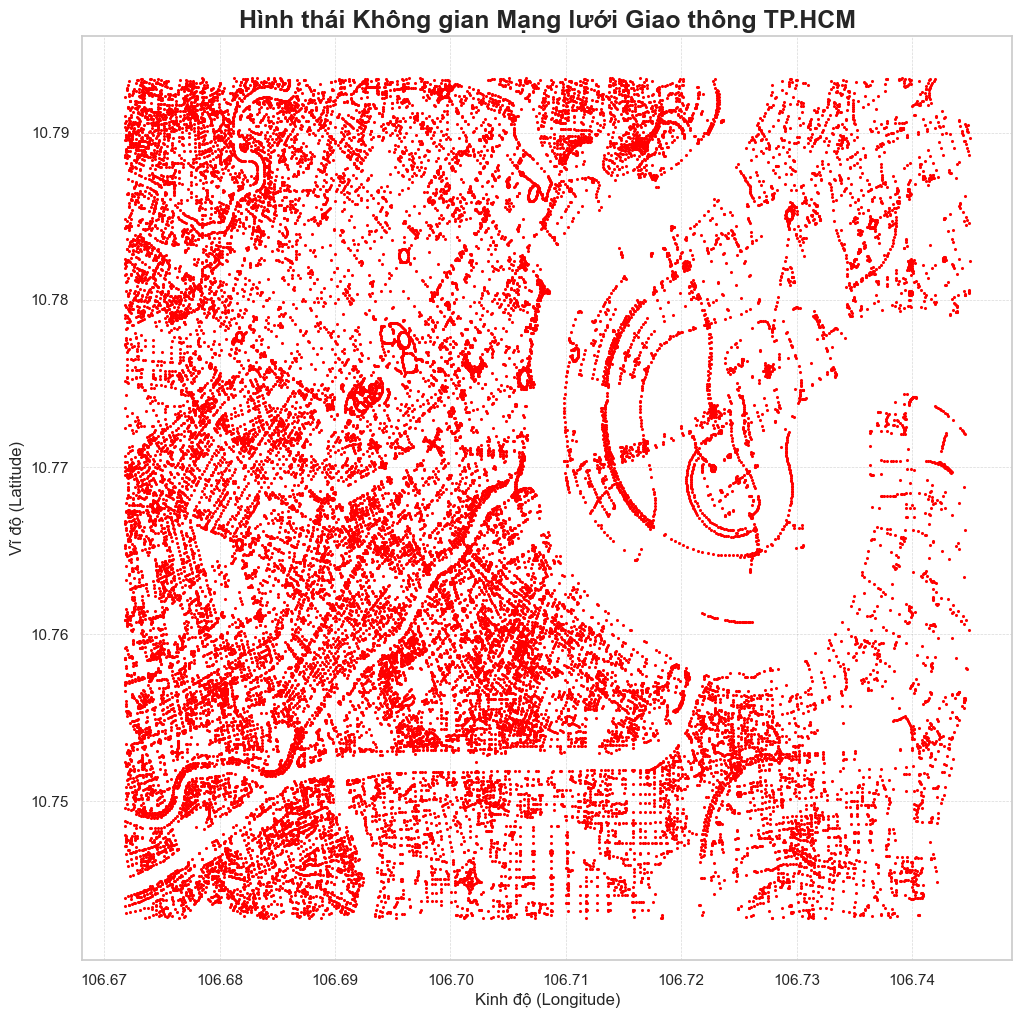

In [2]:
# Thiết lập kích thước biểu đồ
plt.figure(figsize=(12, 12))

# Vẽ đồ thị phân tán (Scatter Plot) với x là Kinh độ, y là Vĩ độ
plt.scatter(nodes_df['x'], nodes_df['y'], s=1.5, c='red', alpha=1)

plt.title('Hình thái Không gian Mạng lưới Giao thông TP.HCM', fontsize=18, fontweight='bold')
plt.xlabel('Kinh độ (Longitude)', fontsize=12)
plt.ylabel('Vĩ độ (Latitude)', fontsize=12)

# Chỉnh nền tối cho biểu đồ để các điểm xanh nổi bật hơn
plt.gca().set_facecolor("#ffffff")
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
plt.show()

Mỗi đoạn đường có một mảng `los` gồm 48 phần tử tương ứng với 48 khung giờ trong ngày (mỗi 30 phút). Ta sẽ tính trung bình mức độ kẹt xe của TOÀN BỘ các đoạn đường trong từng khung giờ để tìm ra quy luật "Giờ cao điểm".